# Task - 1:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_df = '/content/drive/MyDrive/AIML(week5)/FruitinAmazon/FruitinAmazon/train'
test_df = '/content/drive/MyDrive/AIML(week5)/FruitinAmazon/FruitinAmazon/test'

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [6]:
import os
class_names = sorted(os.listdir(train_df))

if not class_names:
    print("No class directories found in the train")
else:
    print(f"Found {len(class_names)} \nclasses: {class_names}")

Found 6 
classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
from PIL import Image, UnidentifiedImageError
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")



No corrupted images found.


In [8]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [9]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

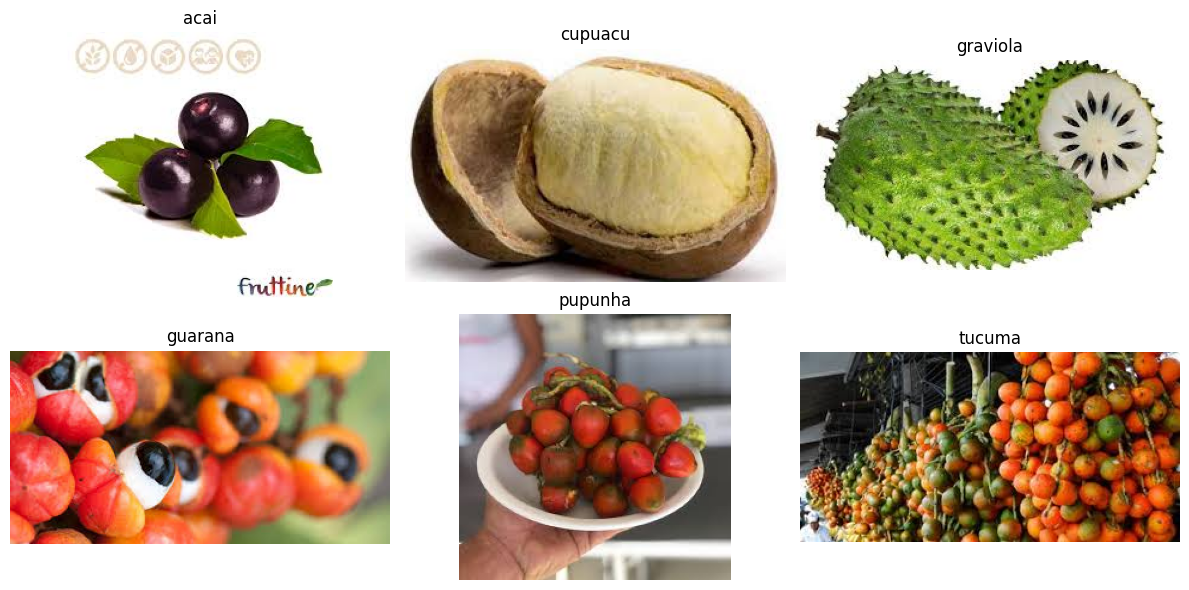

In [10]:
import matplotlib.image as mpimg

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
def load_datasets(dataset_path, img_size=(128, 128), batch_size=32):
    train_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )
    val_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )
    return train_ds, val_ds

train_ds, val_ds = load_datasets(train_df)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [17]:
def build_cnn_model(input_shape, num_classes):
    cnn_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return cnn_model

input_shape = (128, 128, 3)
class_names = train_ds.class_names
cnn_model = build_cnn_model(input_shape, len(class_names))

In [18]:
def compile_model(model):
    cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return cnn_model

cnn_model = compile_model(cnn_model)
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
def train_model(model, train_ds, val_ds, epochs=250, batch_size=16):
    callbacks = [
        keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
    cnn_model.fit(train_ds, validation_data=val_ds, epochs=epochs, batch_size=batch_size, callbacks=callbacks)
    return cnn_model

# Example usage:
cnn_model = train_model(cnn_model, train_ds, val_ds)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1493 - loss: 67.8884

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 685ms/step - accuracy: 0.1667 - loss: 98.7501 - val_accuracy: 0.0556 - val_loss: 219.4962
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.1892 - loss: 153.6573

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 480ms/step - accuracy: 0.2083 - loss: 132.2254 - val_accuracy: 0.1667 - val_loss: 35.6217
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.3044 - loss: 32.1379

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 746ms/step - accuracy: 0.3194 - loss: 27.7261 - val_accuracy: 0.2222 - val_loss: 7.8815
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.5064 - loss: 5.3089

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 547ms/step - accuracy: 0.4722 - loss: 5.0789 - val_accuracy: 0.3889 - val_loss: 4.0888
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5833 - loss: 1.4275

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 740ms/step - accuracy: 0.6250 - loss: 1.2844 - val_accuracy: 0.3333 - val_loss: 1.9457
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.8154 - loss: 0.5934

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 0.8056 - loss: 0.5988 - val_accuracy: 0.3333 - val_loss: 1.7919
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9444 - loss: 0.3794 - val_accuracy: 0.4444 - val_loss: 2.1732
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9583 - loss: 0.2119 - val_accuracy: 0.2778 - val_loss: 2.6339
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.9722 - loss: 0.1303 - val_accuracy: 0.2778 - val_loss: 3.0879
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 613ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 0.2778 - val_loss: 3.2311
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 729ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.3333 - val_loss: 3.2512
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.3889 - val_loss: 3.3995
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 678ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.4444 - val_loss: 3.555

In [20]:
def evaluate_model(model, test_ds):
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

evaluate_model(cnn_model, val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3333 - loss: 1.7919
Test Accuracy: 0.3333
Test Loss: 1.7919


In [21]:
def save_model(model, filename="model.h5"):
    model.save(filename)

def load_model(filename="model.h5"):
    return keras.models.load_model(filename)

save_model(cnn_model)
cnn_model = load_model()

In [22]:
from sklearn.metrics import classification_report

In [23]:
def make_predictions(model, test_ds, class_names):
    y_true, y_pred = [], []

    for images, labels in test_ds:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

make_predictions(cnn_model, val_ds, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
              precision    recall  f1-score   support

        acai       0.33      1.00      0.50         3
     cupuacu       0.00      0.00      0.00         4
    graviola       0.20      1.00      0.33         1
     guarana       0.50      0.33      0.40         3
     pupunha       0.00      0.00      0.00         4
      tucuma       0.50      0.33      0.40         3

    accuracy                           0.33        18
   macro avg       0.26      0.44      0.27        18
weighted avg       0.23      0.33      0.24        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dropout, BatchNormalization,
                                     Activation, Flatten, Dense)
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [25]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [26]:
model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output layer
    Dense(6, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True),
    EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1991 - loss: 2.4103

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.2222 - loss: 2.4191 - val_accuracy: 0.1667 - val_loss: 1.7944
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3056 - loss: 1.8517 - val_accuracy: 0.2222 - val_loss: 1.8599
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3472 - loss: 1.6484 - val_accuracy: 0.1111 - val_loss: 2.0853
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3750 - loss: 1.6168 - val_accuracy: 0.0556 - val_loss: 2.3911
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5139 - loss: 1.4465 - val_accuracy: 0.0556 - val_loss: 2.7134
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5556 - loss: 1.3126 - val_accuracy: 0.0556 - val_loss: 2.9602
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.5972 - loss: 0.9534 - val_accuracy: 0.0556 - val_loss: 3.2965
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6111 - loss: 0.9817 - val_accuracy: 0.0556 - val_loss: 3.5924
Epoch 9/50
3/3 ━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task - 2:

In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

base_model = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(128, 128, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

In [30]:
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
callbacks = [
    ModelCheckpoint("best_vgg_model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)
test_loss, test_acc = model.evaluate(val_ds)
print(f"Transfer Learning Model Accuracy: {test_acc:.4f}")
print(f"Transfer Learning Model Loss: {test_loss:.4f}")

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2506 - loss: 12.4042

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.2361 - loss: 12.8324 - val_accuracy: 0.2222 - val_loss: 4.6157
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3102 - loss: 8.2824

3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.3056 - loss: 8.6494 - val_accuracy: 0.3333 - val_loss: 4.3149
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1545 - loss: 12.8333

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.1667 - loss: 12.2829 - val_accuracy: 0.4444 - val_loss: 4.1472
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1597 - loss: 10.8228

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.1667 - loss: 9.8416 - val_accuracy: 0.4444 - val_loss: 3.9271
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2558 - loss: 8.2445

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.4028 - loss: 5.5665 - val_accuracy: 0.5556 - val_loss: 3.2114
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6071 - loss: 3.0504

3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.5556 - loss: 3.3606 - val_accuracy: 0.5556 - val_loss: 3.1138
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5567 - loss: 3.9077

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.5139 - loss: 4.8206 - val_accuracy: 0.6111 - val_loss: 2.9398
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6267 - loss: 4.0037

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.5833 - loss: 4.2709 - val_accuracy: 0.5556 - val_loss: 2.7381
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5098 - loss: 3.7135

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5139 - loss: 3.4643 - val_accuracy: 0.5000 - val_loss: 2.6452
Epoch 19/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.5694 - loss: 3.0722 - val_accuracy: 0.5556 - val_loss: 2.6729
Epoch 20/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.5694 - loss: 3.5708 - val_accuracy: 0.5000 - val_loss: 2.8062
Epoch 21/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.7500 - loss: 2.4216 - val_accuracy: 0.5000 - val_loss: 2.8486
Epoch 22/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.6250 - loss: 2.3381 - val_accuracy: 0.5556 - val_loss: 2.8118
Epoch 23/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.6250 - loss: 2.7329 - val_accuracy: 0.5556 - val_loss: 2.8384
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 2.6452
Transfer Learning Model Accuracy: 0.5000
Transfer Learning Model Loss: 2.6452

Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00  

In [32]:
from sklearn.metrics import classification_report

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_df,
    image_size=(128, 128),  # Original image size
    batch_size=32,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_df,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=42
)

class_names = train_ds.class_names
num_classes = len(class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Build Transfer Learning Model
inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Resizing(224, 224)(x)

# Load VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  #freeze base model

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# train model
callbacks = [
    ModelCheckpoint("best_vgg_model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTransfer Learning Model Accuracy: {test_acc:.4f}")
print(f"Transfer Learning Model Loss: {test_loss:.4f}")

# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,422 (57.15 MB)

 Trainable params: 265,734 (1.01 MB)

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.2083 - loss: 2.0750 - val_accuracy: 0.1667 - val_loss: 1.8272
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.1337 - loss: 2.2175 

3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.1667 - loss: 2.1445 - val_accuracy: 0.1667 - val_loss: 1.7971
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.1742 - loss: 2.0001 

3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.1944 - loss: 1.9688 - val_accuracy: 0.1667 - val_loss: 1.7828
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1904 - loss: 1.9441 

3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 15s/step - accuracy: 0.1806 - loss: 1.9642 - val_accuracy: 0.1667 - val_loss: 1.7750
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 16s/step - accuracy: 0.2083 - loss: 1.8875 - val_accuracy: 0.1111 - val_loss: 1.7758
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.1806 - loss: 1.8653 - val_accuracy: 0.1667 - val_loss: 1.7783
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - accuracy: 0.1944 - loss: 1.9094 - val_accuracy: 0.1667 - val_loss: 1.7792
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 16s/step - accuracy: 0.1944 - loss: 1.8662 - val_accuracy: 0.2222 - val_loss: 1.7812
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 96s 23s/step - accuracy: 0.3194 - loss: 1.7516 - val_accuracy: 0.1667 - val_loss: 1.7845
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.1667 - loss: 1.7750

Transfer Learning Model Accuracy: 0.1667
Transfer Learning Model Loss: 1.7750

Classification Report:
              precision    recall  f1-score   support

        acai       0.12      0.6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
